# FrozenLake Shielding Comparison

This notebook compares baseline and shielded policy-gradient agents on `FrozenLake-v1`.

We evaluate six settings:

1. `A2C`
2. `PPO`
3. `SA2C (oracle)`
4. `SPPO (oracle)`
5. `SA2C (pretrained MLP)`
6. `SPPO (pretrained MLP)`

The goal is to study reward and safety behavior under different sensor assumptions.


In [1]:
# Bootstrap cell: run this once (safe to re-run)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym

from pathlib import Path
import importlib.util

from stable_baselines3 import A2C, PPO
from stable_baselines3.common.callbacks import BaseCallback

from pls.algorithms.a2c_shielded import A2C_shielded
from pls.algorithms.ppo_shielded import PPO_shielded

# Robust local import for research registration utilities.
_repo_root = Path.cwd().resolve()
if not (_repo_root / "examples" / "train_a_policy" / "frozenlake_plugin" / "research_registration.py").exists():
    if (_repo_root.parent / "examples" / "train_a_policy" / "frozenlake_plugin" / "research_registration.py").exists():
        _repo_root = _repo_root.parent

_rr_path = _repo_root / "examples" / "train_a_policy" / "frozenlake_plugin" / "research_registration.py"
if not _rr_path.exists():
    raise FileNotFoundError(f"Could not find research_registration.py at {_rr_path}")

_spec = importlib.util.spec_from_file_location("cleanpls_frozenlake_registration", _rr_path)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
register_for_research = _mod.register_for_research
FrozenLakeGridSensor = _mod.FrozenLakeGridSensor

TOTAL_TIMESTEPS = 10000
SEEDS = [0, 1, 2]
WINDOW = 20
SHIELD_ALPHA = 0.1
MAP_NAME = "4x4"
IS_SLIPPERY = True

register_for_research()

def resolve_shield_program():
    candidates = [
        Path.cwd() / 'examples' / 'train_a_policy' / 'data' / 'frozenlake_safe_start.pl',
        Path.cwd() / 'train_a_policy' / 'data' / 'frozenlake_safe_start.pl',
        Path.cwd().parent / 'examples' / 'train_a_policy' / 'data' / 'frozenlake_safe_start.pl',
    ]
    for pp in candidates:
        if pp.exists():
            return pp.resolve()
    raise FileNotFoundError('Could not find frozenlake_safe_start.pl')

PROGRAM = resolve_shield_program()
plt.style.use('ggplot')
print('Bootstrap complete. PROGRAM =', PROGRAM)


Bootstrap complete. PROGRAM = /Users/satch/Documents/pls/examples/train_a_policy/data/frozenlake_safe_start.pl


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 1) Imports and Experiment Setup

We import:

- RL algorithms (`A2C`, `PPO`) and shielded variants.
- plotting and numerical utilities.
- registration utilities for the research runtime.

This section also sets global knobs such as training horizon and seeds.


In [2]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from stable_baselines3 import A2C, PPO
from stable_baselines3.common.callbacks import BaseCallback

from pls.algorithms.a2c_shielded import A2C_shielded
from pls.algorithms.ppo_shielded import PPO_shielded
from pathlib import Path
import importlib.util

# Robust local import for research registration utilities.
# Works whether running from repo root or from examples/.
_repo_root = Path.cwd().resolve()
if not (_repo_root / "examples" / "train_a_policy" / "frozenlake_plugin" / "research_registration.py").exists():
    # if launched inside examples/, move one level up
    if (_repo_root.parent / "examples" / "train_a_policy" / "frozenlake_plugin" / "research_registration.py").exists():
        _repo_root = _repo_root.parent

_rr_path = _repo_root / "examples" / "train_a_policy" / "frozenlake_plugin" / "research_registration.py"
if not _rr_path.exists():
    raise FileNotFoundError(f"Could not find research_registration.py at {_rr_path}")

_spec = importlib.util.spec_from_file_location("cleanpls_frozenlake_registration", _rr_path)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
register_for_research = _mod.register_for_research
FrozenLakeGridSensor = _mod.FrozenLakeGridSensor


## 2) Register FrozenLake Runtime Components

`register_for_research()` connects the environment, sensor wrappers, and runtime adapters to the CleanPLS registry.

This makes the experiment config-driven and avoids hardcoding environment-specific branching.


In [3]:
# Optional: bootstrap already defines these globals; re-running this cell is safe.
TOTAL_TIMESTEPS = 10000
SEEDS = [0, 1, 2]
WINDOW = 20
SHIELD_ALPHA = 0.1
MAP_NAME = '4x4'
IS_SLIPPERY = True

register_for_research()


def resolve_shield_program():
    candidates = [
        Path.cwd() / 'examples' / 'train_a_policy' / 'data' / 'frozenlake_safe_start.pl',
        Path.cwd() / 'train_a_policy' / 'data' / 'frozenlake_safe_start.pl',
        Path.cwd().parent / 'examples' / 'train_a_policy' / 'data' / 'frozenlake_safe_start.pl',
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError('Could not find frozenlake_safe_start.pl')

PROGRAM = resolve_shield_program()

plt.style.use('ggplot')


## 3) Pretrain an MLP Sensor (Research Proxy)

This cell trains a lightweight MLP to predict sensor outputs from observations.

Interpretation:

- **Oracle sensor**: idealized, rule-grounded sensing.
- **Pretrained MLP sensor**: learned approximation with potential errors.

Comparing both helps isolate sensitivity to sensor quality.


In [4]:


class FrozenLakeSensorMLP(nn.Module):
    def __init__(self, in_dim=16, hidden_sizes=(16, 16), out_dim=4):
        super().__init__()
        layers = []
        last = in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers += [nn.Linear(last, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

import gymnasium as gym
from gymnasium import Wrapper

class EpisodeInfoWrapper(Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self._ep_reward = 0.0

    def reset(self, **kwargs):
        self._ep_reward = 0.0
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._ep_reward += float(reward)
        done = bool(terminated or truncated)
        if done:
            info = dict(info)
            info['episode_reward'] = self._ep_reward
            # FrozenLake safety proxy: failure if goal not reached.
            info['episode_failure'] = float(self._ep_reward < 1.0)
        return obs, reward, terminated, truncated, info

class SafetyRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.episode_failure = []
        self.episode_end_steps = []

    def _on_step(self) -> bool:
        infos = self.locals.get('infos', [])
        for info in infos:
            if isinstance(info, dict) and 'episode_reward' in info:
                r = float(info['episode_reward'])
                f = float(info.get('episode_failure', r < 1.0))
                self.episode_rewards.append(r)
                self.episode_failure.append(f)
                self.episode_end_steps.append(int(self.num_timesteps))
        return True

def make_env(seed):
    env = gym.make('FrozenLake-v1', map_name=MAP_NAME, is_slippery=IS_SLIPPERY)
    env = EpisodeInfoWrapper(env)
    env.reset(seed=seed)
    return env


def pretrain_frozenlake_sensor(seed=0, epochs=60, lr=1e-2):
    rng = np.random.default_rng(seed)
    n_states = 16
    states = np.arange(n_states, dtype=np.int64)

    labels = []
    for s in states:
        row, col = divmod(int(s), 4)
        labels.append([
            float(s == 0),
            float(s == 15),
            float(row == 0),
            float(col == 0),
        ])
    # one-hot encode discrete FrozenLake states -> shape (num_states, num_states)
    n_states = int(states.max()) + 1
    x = np.eye(n_states, dtype=np.float32)[states]
    y = np.asarray(labels, dtype=np.float32)

    try:
        SensorCls = FrozenLakeSensorMLP
    except NameError:
        class FrozenLakeSensorMLP(nn.Module):
            def __init__(self, in_dim=16, hidden_sizes=(16, 16), out_dim=4):
                super().__init__()
                layers = []
                last = in_dim
                for h in hidden_sizes:
                    layers += [nn.Linear(last, h), nn.ReLU()]
                    last = h
                layers += [nn.Linear(last, out_dim)]
                self.net = nn.Sequential(*layers)

            def forward(self, x):
                return self.net(x)
        SensorCls = FrozenLakeSensorMLP

    model = SensorCls(hidden_sizes=(16, 16), out_dim=4)
    opt = __import__('torch').optim.Adam(model.parameters(), lr=lr)
    import torch as th
    loss_fn = th.nn.BCEWithLogitsLoss()

    xb = th.tensor(x, dtype=th.float32)
    yb = th.tensor(y, dtype=th.float32)
    if xb.ndim != 2 or xb.shape[1] != 16:
        raise RuntimeError(f"Expected xb shape (N,16) for FrozenLake-4x4, got {tuple(xb.shape)}")
    for _ in range(epochs):
        opt.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()

    class FrozenLakePretrainedMLPSensor:
        def __init__(self, m):
            self.m = m.eval()
        def predict(self, obs, info=None):
            del info
            arr = np.asarray(obs)
            if arr.ndim == 0:
                arr = np.array([arr])
            arr = arr.astype(np.int64).reshape(-1)
            feats = np.eye(16, dtype=np.float32)[arr]
            t = th.as_tensor(feats, dtype=th.float32)
            with th.no_grad():
                return th.sigmoid(self.m(t)).clamp(0, 1)

    return FrozenLakePretrainedMLPSensor(model)


def build_sensor(sensor_kind):
    if sensor_kind == 'oracle':
        return FrozenLakeGridSensor(grid_size=4)
    if sensor_kind == 'mlp':
        return pretrain_frozenlake_sensor(seed=0)
    raise ValueError(sensor_kind)


def shield_parts(sensor_kind):
    sensor_model = build_sensor(sensor_kind)
    shield_params = {
        'num_sensors': 4,
        'num_actions': 4,
        'shield_program': PROGRAM.name,
        'sensor_model': sensor_model,
        'observation_type': 'ground truth',
    }
    policy_kwargs = {
        'shield_params': shield_params,
        'net_arch': dict(pi=[64, 64], vf=[64, 64]),
        'config_folder': str(PROGRAM.parent),
        'get_sensor_value_ground_truth': lambda x: x,
    }
    safety_params = {
        'num_sensors': 4,
        'num_actions': 4,
        'shield_program': PROGRAM.name,
        'sensor_model': sensor_model,
        'observation_type': 'ground truth',
        'config_folder': str(PROGRAM.parent),
        'get_sensor_value_ground_truth': lambda x: x,
    }
    return policy_kwargs, safety_params


def train_variant(name, seed, timesteps):
    env = make_env(seed)
    cb = SafetyRewardCallback()

    if name == 'A2C':
        model = A2C('MlpPolicy', env, seed=seed, verbose=0, n_steps=64, learning_rate=7e-4, gamma=0.99)
    elif name == 'PPO':
        model = PPO('MlpPolicy', env, seed=seed, verbose=0, n_steps=128, batch_size=64, n_epochs=4, learning_rate=3e-4, gamma=0.99)
    elif name == 'SA2C (oracle)':
        policy_kwargs, safety_params = shield_parts('oracle')
        model = A2C_shielded(env=env, seed=seed, verbose=0, n_steps=64, learning_rate=7e-4, gamma=0.99, alpha=SHIELD_ALPHA, policy_kwargs=policy_kwargs, policy_safety_params=safety_params)
    elif name == 'SPPO (oracle)':
        policy_kwargs, safety_params = shield_parts('oracle')
        model = PPO_shielded(env=env, seed=seed, verbose=0, n_steps=128, batch_size=64, n_epochs=4, learning_rate=3e-4, gamma=0.99, clip_range=0.2, alpha=SHIELD_ALPHA, policy_kwargs=policy_kwargs, policy_safety_params=safety_params)
    elif name == 'SA2C (pretrained MLP)':
        policy_kwargs, safety_params = shield_parts('mlp')
        model = A2C_shielded(env=env, seed=seed, verbose=0, n_steps=64, learning_rate=7e-4, gamma=0.99, alpha=SHIELD_ALPHA, policy_kwargs=policy_kwargs, policy_safety_params=safety_params)
    elif name == 'SPPO (pretrained MLP)':
        policy_kwargs, safety_params = shield_parts('mlp')
        model = PPO_shielded(env=env, seed=seed, verbose=0, n_steps=128, batch_size=64, n_epochs=4, learning_rate=3e-4, gamma=0.99, clip_range=0.2, alpha=SHIELD_ALPHA, policy_kwargs=policy_kwargs, policy_safety_params=safety_params)
    else:
        raise ValueError(name)

    model.learn(total_timesteps=timesteps, callback=cb)
    return pd.DataFrame({
        'variant': name,
        'seed': seed,
        'episode_idx': np.arange(len(cb.episode_rewards)),
        'episode_reward': cb.episode_rewards,
        'failure': cb.episode_failure,
        'timestep': cb.episode_end_steps,
    })


## 4) Run the Six Experimental Conditions

Each condition is trained with matched seeds and comparable budgets.

For shielded agents, the shield updates action selection based on sensor outputs and a ProbLog safety program.

Near-decision diagnostics:

- reward trajectory (task performance)
- failure-rate proxy (safety behavior)


In [5]:
variants = [
    'SPPO (pretrained MLP)',
    'SA2C (pretrained MLP)',
    'SA2C (oracle)',
    'SPPO (oracle)',
    'A2C',
    'PPO',
]

frames = []
for variant in variants:
    for seed in SEEDS:
        print(f'Training {variant} (seed={seed})...')
        frames.append(train_variant(variant, seed, TOTAL_TIMESTEPS))

all_runs = pd.concat(frames, ignore_index=True)
all_runs.head()


Training SPPO (pretrained MLP) (seed=0)...
Training SPPO (pretrained MLP) (seed=1)...
Training SPPO (pretrained MLP) (seed=2)...
Training SA2C (pretrained MLP) (seed=0)...
Training SA2C (pretrained MLP) (seed=1)...
Training SA2C (pretrained MLP) (seed=2)...
Training SA2C (oracle) (seed=0)...
Training SA2C (oracle) (seed=1)...
Training SA2C (oracle) (seed=2)...
Training SPPO (oracle) (seed=0)...
Training SPPO (oracle) (seed=1)...
Training SPPO (oracle) (seed=2)...
Training A2C (seed=0)...
Training A2C (seed=1)...
Training A2C (seed=2)...
Training PPO (seed=0)...
Training PPO (seed=1)...
Training PPO (seed=2)...


,variant,seed,episode_idx,episode_reward,failure,timestep
0,SPPO (pretrained MLP),0,0,0.0,1.0,4
1,SPPO (pretrained MLP),0,1,0.0,1.0,18
2,SPPO (pretrained MLP),0,2,0.0,1.0,20
3,SPPO (pretrained MLP),0,3,0.0,1.0,22
4,SPPO (pretrained MLP),0,4,0.0,1.0,24


## 5) Plot Learning and Safety Curves

We visualize moving averages to reduce stochastic noise:

- **Reward curve**: progress toward solving the task.
- **Failure-rate curve**: fraction of episodes not reaching success (`reward < 1.0`), used as a practical safety proxy on FrozenLake.

Lower failure rate is better.


## 6) Aggregate Across Seeds

Final tables summarize mean and variability across seeds.

Use these summaries for reporting:

- central tendency (mean)
- spread (std / confidence estimate)

This supports reproducible baseline vs shielded comparisons.


In [9]:
summary = all_runs.groupby(['variant', 'seed']).agg(
    mean_episode_reward=('episode_reward', 'mean'),
    failure_rate=('failure', 'mean'),
    episodes=('episode_idx', 'count')
).reset_index()

summary.groupby('variant')[['mean_episode_reward', 'failure_rate']].mean().sort_values('mean_episode_reward', ascending=False)


,mean_episode_reward,failure_rate
variant,,
SA2C (oracle),0.030047,0.969953
SA2C (pretrained MLP),0.028944,0.971056
PPO,0.020980,0.979020
SPPO (pretrained MLP),0.018836,0.981164
SPPO (oracle),0.018551,0.981449
A2C,0.017422,0.982578


In [10]:
def smooth_per_run(df, value_col, window=20):
    out = df.copy()
    out[value_col + '_smooth'] = (
        out.sort_values('episode_idx')
           .groupby(['variant', 'seed'])[value_col]
           .transform(lambda s: s.rolling(window=window, min_periods=1).mean())
    )
    return out

reward_df = smooth_per_run(all_runs, 'episode_reward', WINDOW)
failure_df = smooth_per_run(all_runs, 'failure', WINDOW)

reward_mean = reward_df.groupby(['variant', 'episode_idx'])['episode_reward_smooth'].mean().reset_index()
failure_mean = failure_df.groupby(['variant', 'episode_idx'])['failure_smooth'].mean().reset_index()


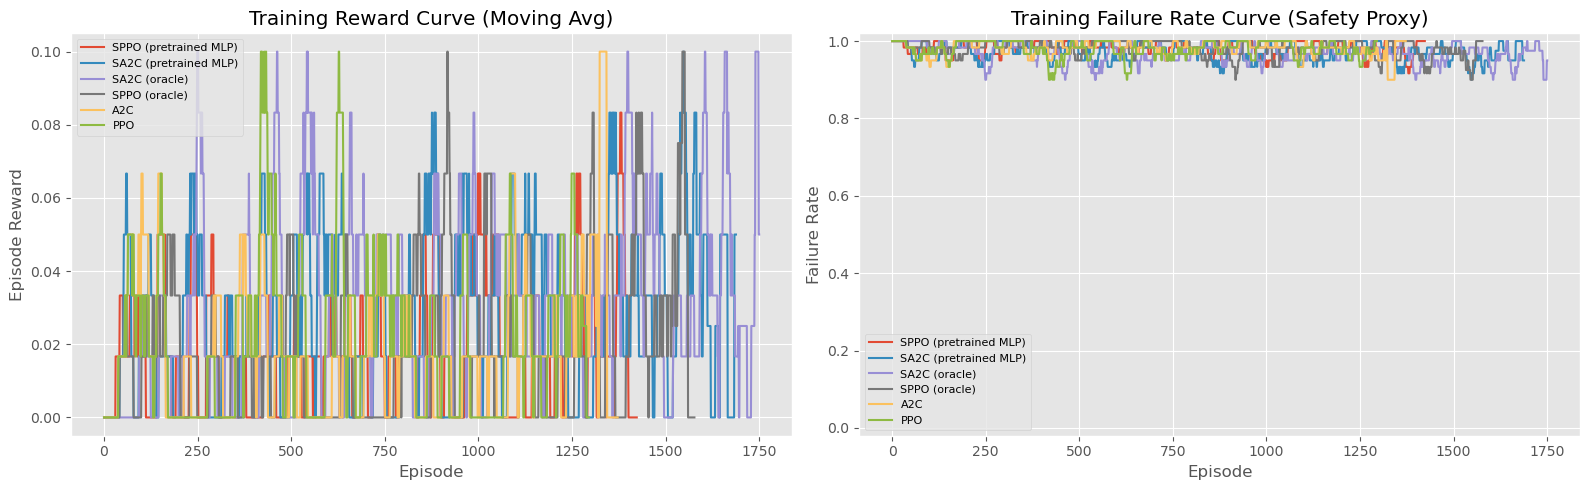

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for variant in variants:
    d = reward_mean[reward_mean['variant'] == variant]
    axes[0].plot(d['episode_idx'], d['episode_reward_smooth'], label=variant)
axes[0].set_title('Training Reward Curve (Moving Avg)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].legend(fontsize=8)

for variant in variants:
    d = failure_mean[failure_mean['variant'] == variant]
    axes[1].plot(d['episode_idx'], d['failure_smooth'], label=variant)
axes[1].set_title('Training Failure Rate Curve (Safety Proxy)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Failure Rate')
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Interpretation Notes

Typical reading pattern:

- If shielded variants reduce failure rate with small reward cost, shielding improves safety-performance balance.
- If pretrained-MLP shielding underperforms oracle shielding, sensor quality is likely the limiting factor.
- If PPO and A2C differ strongly, optimizer stability may dominate shield effects under the same safety logic.

For robust conclusions, repeat with more seeds and sweep shield strength parameters.
